In [52]:
import pandas as pd
df=pd.read_csv("Ads_Sale.csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [53]:
df.shape

(200, 4)

In [54]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

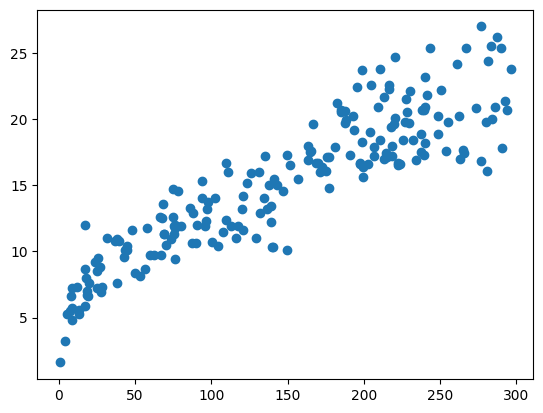

In [55]:
import matplotlib.pyplot as plt
plt.scatter(x=df['TV'],y=df['Sales'])
plt.show()

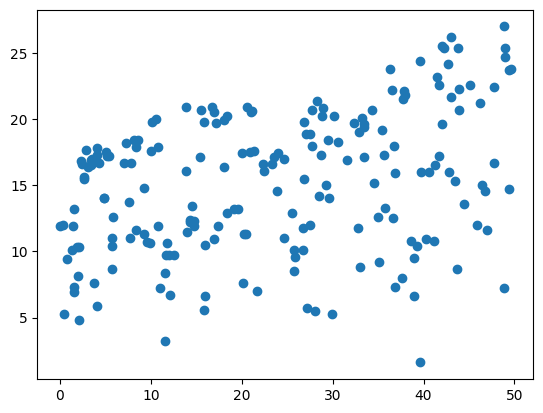

In [56]:
import matplotlib.pyplot as plt
plt.scatter(x=df['Radio'],y=df['Sales'])
plt.show()

In [4]:
X=df[['TV','Radio','Newspaper']]
y=df['Sales']

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=23)

In [43]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_train_scaled = ss.fit_transform(x_train)
x_test_scaled = ss.fit_transform(x_test)


In [44]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()


In [45]:
lr.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
y_pred = lr.predict(x_test_scaled)
y_pred

array([ 9.01537526, 22.55618535, 20.57345071, 13.43635089, 18.39046151,
        6.94418113, 16.08705542, 14.39935675, 23.5461369 , 16.24592009,
       19.5338212 ,  9.8930472 , 10.06896551, 17.33529747,  9.2791946 ,
       17.25171821, 12.29595753,  8.82670405, 19.22118513,  9.82104944,
       23.77224773, 19.88247974, 16.48012689,  8.3679098 ,  7.39484543,
       23.80640403, 20.37049435, 16.19045333, 10.44876295, 10.3410784 ,
       18.57047139,  9.97646694, 15.64019425,  9.08824702, 18.23453892,
       19.97303713,  4.89224618, 15.12949748, 18.65220965, 16.34187402])

In [47]:
from sklearn.metrics import r2_score
acc = r2_score(y_test,y_pred)
acc

0.8988639100780523

In [65]:
import numpy as np
tv=200
radio=60.6
Newspaper = 45

def predictive_system(tv,radio,Newspaper):
    features=np.array([[tv,radio,Newspaper]])
    features=ss.transform(features)
    results=lr.predict(features).reshape(1,-1)
    return results[0]
predicted_sale= predictive_system(tv,radio,Newspaper)
print(predicted_sale)

[20.93937942]


In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("mail_data.csv")
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
df.shape

(5572, 2)

In [4]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [5]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
print(ENGLISH_STOP_WORDS)
print(len(ENGLISH_STOP_WORDS))

frozenset({'who', 'except', 'amongst', 'a', 'been', 'eleven', 'three', 'even', 'please', 'wherever', 'forty', 'bill', 'find', 'his', 'until', 'part', 'against', 'onto', 'herein', 'six', 'among', 'on', 'these', 'alone', 'what', 'eight', 'elsewhere', 'could', 'through', 'whose', 'cry', 'it', 'for', 'hundred', 'can', 'together', 'ie', 'across', 'no', 'yourselves', 'anywhere', 'whereas', 'off', 'anyone', 'how', 'twelve', 'herself', 'hence', 'becoming', 'once', 'more', 'while', 'any', 'they', 'toward', 'everything', 'former', 'call', 'that', 'mine', 'them', 'not', 'wherein', 'if', 'besides', 'describe', 'co', 'amoungst', 'take', 'therein', 'might', 'but', 'seem', 'her', 'done', 'nor', 'always', 'go', 'which', 'so', 'others', 'although', 'due', 'became', 'fifty', 'first', 'within', 'seemed', 'thru', 'and', 'hasnt', 'beside', 'above', 'therefore', 'up', 'or', 'to', 'found', 'myself', 'have', 'de', 'themselves', 'fire', 'latter', 'most', 'without', 'noone', 'formerly', 'she', 'at', 'there', 't

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
text = ["This is a free offer for today, so hurryup!"]
vector = TfidfVectorizer(stop_words='english')
X = vector.fit_transform(text)
print(vector.get_feature_names_out())

['free' 'hurryup' 'offer' 'today']


In [7]:
print(X)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4 stored elements and shape (1, 4)>
  Coords	Values
  (0, 0)	0.5
  (0, 2)	0.5
  (0, 3)	0.5
  (0, 1)	0.5


In [8]:
#Encoding process
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])

In [9]:
#1--> spam
#0-->ham
df['Category']

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Category, Length: 5572, dtype: int64

In [10]:
#Seperate data
X=df['Message'] #text of mail
y = df['Category'] # label for that mail

In [11]:
X.head()

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: Message, dtype: object

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=3)

In [13]:
X.shape, X_train.shape,X_test.shape

((5572,), (4457,), (1115,))

In [14]:
y.shape,y_train.shape,y_test.shape

((5572,), (4457,), (1115,))

In [15]:
print(X_train.head(2))

3075                  Don know. I did't msg him recently.
1787    Do you know why god created gap between your f...
Name: Message, dtype: object


In [16]:

print(y_train.head(2))

3075    0
1787    0
Name: Category, dtype: int64


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
vector = TfidfVectorizer(stop_words='english',lowercase=True)
X_train_feature = vector.fit_transform(X_train)


In [18]:
X_test_feature = vector.transform(X_test)

In [19]:
print(X_test_feature)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7687 stored elements and shape (1115, 7431)>
  Coords	Values
  (0, 1)	0.2381316303003606
  (0, 9)	0.2852706805264544
  (0, 14)	0.26797874471323896
  (0, 20)	0.30668032384591537
  (0, 306)	0.23975986557206702
  (0, 405)	0.2381316303003606
  (0, 1041)	0.28016206931555726
  (0, 1082)	0.2451068436245027
  (0, 1361)	0.25132445289897426
  (0, 1405)	0.3176863938914351
  (0, 1549)	0.2646498848307188
  (0, 4386)	0.18353336340308998
  (0, 5213)	0.1988547357502182
  (0, 5373)	0.2365698724638063
  (0, 6920)	0.20571591693537986
  (0, 7271)	0.1940327008179069
  (1, 3491)	0.496093956101028
  (1, 4418)	0.3457696891316818
  (1, 4729)	0.22965776503163893
  (1, 6214)	0.3621564482127515
  (1, 6507)	0.26731535902873493
  (1, 6588)	0.3298937975962767
  (1, 6732)	0.42473488678029325
  (1, 7368)	0.29957800964520975
  (2, 201)	0.2824102268489399
  :	:
  (1110, 6591)	0.7327660015422193
  (1111, 2440)	0.4137350055985486
  (1111, 3227)	0.44384935772735

In [20]:
X_test_feature = vector.transform(X_test)
#print(x_test_features)
X_test = pd.DataFrame(
    X_test_feature.toarray(),
    columns=vector.get_feature_names_out()
)
print(X_test.head())

    00       000  000pes  008704050406  0089  0121  01223585236  01223585334  \
0  0.0  0.238132     0.0           0.0   0.0   0.0          0.0          0.0   
1  0.0  0.000000     0.0           0.0   0.0   0.0          0.0          0.0   
2  0.0  0.000000     0.0           0.0   0.0   0.0          0.0          0.0   
3  0.0  0.000000     0.0           0.0   0.0   0.0          0.0          0.0   
4  0.0  0.000000     0.0           0.0   0.0   0.0          0.0          0.0   

   0125698789        02  ...  zeros  zindgi  zoe  zogtorius  zoom  zouk  \
0         0.0  0.285271  ...    0.0     0.0  0.0        0.0   0.0   0.0   
1         0.0  0.000000  ...    0.0     0.0  0.0        0.0   0.0   0.0   
2         0.0  0.000000  ...    0.0     0.0  0.0        0.0   0.0   0.0   
3         0.0  0.000000  ...    0.0     0.0  0.0        0.0   0.0   0.0   
4         0.0  0.000000  ...    0.0     0.0  0.0        0.0   0.0   0.0   

   zyada   èn   ú1  〨ud  
0    0.0  0.0  0.0  0.0  
1    0.0  0.0  0

In [21]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train_feature,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
from sklearn.metrics import accuracy_score

training_data=lr.predict(X_train_feature )
training_data

array([0, 0, 0, ..., 0, 0, 1], shape=(4457,))

In [23]:
testing_data=lr.predict(X_test_feature )
testing_data

array([1, 0, 0, ..., 0, 0, 0], shape=(1115,))

In [24]:
y_train

3075    0
1787    0
1614    0
4304    0
3266    1
       ..
789     1
968     0
1667    0
3321    0
1688    1
Name: Category, Length: 4457, dtype: int64

In [25]:
y_test

2632    1
454     0
983     1
1282    0
4610    0
       ..
4827    0
5291    0
3325    0
3561    0
1136    0
Name: Category, Length: 1115, dtype: int64

In [26]:
from sklearn.metrics import accuracy_score

training_acc=accuracy_score(training_data,y_train)
training_acc

0.9676912721561588

In [27]:

testing_acc=accuracy_score(testing_data,y_test)
testing_acc

0.9668161434977578

In [39]:
new_mail = ["Congratulations! 🎉 You have won ₹25,00,000 in the lucky draw. Click here to claim now."]

new_mail_1= vector.transform(new_mail)
prediction = lr.predict(new_mail_1)

if prediction[0] == 1:
    print("Spam Mail")
else:
    print("Not Spam Mail")

Spam Mail


In [40]:
new_mail = ["Dear Customer, update your KYC now to avoid account suspension."]

new_mail_2 = vector.transform(new_mail)
prediction = lr.predict(new_mail_2)

if prediction[0] == 1:
    print("Spam Mail")
else:
    print("Not Spam Mail")

Not Spam Mail
